# **ECORATE - Your Personalised Path To Sustainable Living**

In [38]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [28]:
# Load and inspect dataset
data = pd.read_csv('lifestyle_sustainability_data.csv')  # Replace with your dataset path
data.drop('ParticipantID', axis=1, inplace=True)  # Remove unnecessary ID column

# Check for missing values
print(data.isnull().sum())

Age                                0
Location                           0
DietType                           0
LocalFoodFrequency                 0
TransportationMode                 0
EnergySource                       0
HomeType                           0
HomeSize                           0
ClothingFrequency                  0
SustainableBrands                  0
EnvironmentalAwareness             0
CommunityInvolvement             118
MonthlyElectricityConsumption      0
MonthlyWaterConsumption            0
Gender                             0
UsingPlasticProducts               0
DisposalMethods                    0
PhysicalActivities               108
Rating                             0
dtype: int64


In [29]:
# Fill missing values in 'CommunityInvolvement' and 'PhysicalActivities' with 'Low'
data['CommunityInvolvement'].fillna('Low', inplace=True)
data['PhysicalActivities'].fillna('Low', inplace=True)

# Check for missing values
print(data.isnull().sum())

Age                              0
Location                         0
DietType                         0
LocalFoodFrequency               0
TransportationMode               0
EnergySource                     0
HomeType                         0
HomeSize                         0
ClothingFrequency                0
SustainableBrands                0
EnvironmentalAwareness           0
CommunityInvolvement             0
MonthlyElectricityConsumption    0
MonthlyWaterConsumption          0
Gender                           0
UsingPlasticProducts             0
DisposalMethods                  0
PhysicalActivities               0
Rating                           0
dtype: int64


<ipython-input-29-cfb364cedf2f>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['CommunityInvolvement'].fillna('Low', inplace=True)
<ipython-input-29-cfb364cedf2f>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [30]:
# Encode categorical features
label_encoders = {}
for column in ['Location', 'DietType', 'LocalFoodFrequency', 'TransportationMode', 'EnergySource',
               'HomeType', 'ClothingFrequency', 'SustainableBrands', 'CommunityInvolvement', 'Gender',
               'UsingPlasticProducts', 'DisposalMethods', 'PhysicalActivities']:
    label_encoders[column] = LabelEncoder()
    data[column] = label_encoders[column].fit_transform(data[column])

# Scale numerical features
scaler = StandardScaler()
numerical_features = ['Age', 'HomeSize', 'MonthlyElectricityConsumption', 'MonthlyWaterConsumption',
                      'EnvironmentalAwareness']
data[numerical_features] = scaler.fit_transform(data[numerical_features])

In [31]:
# Split data into features (X) and target (y)
X = data.drop('Rating', axis=1)
y = data['Rating']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

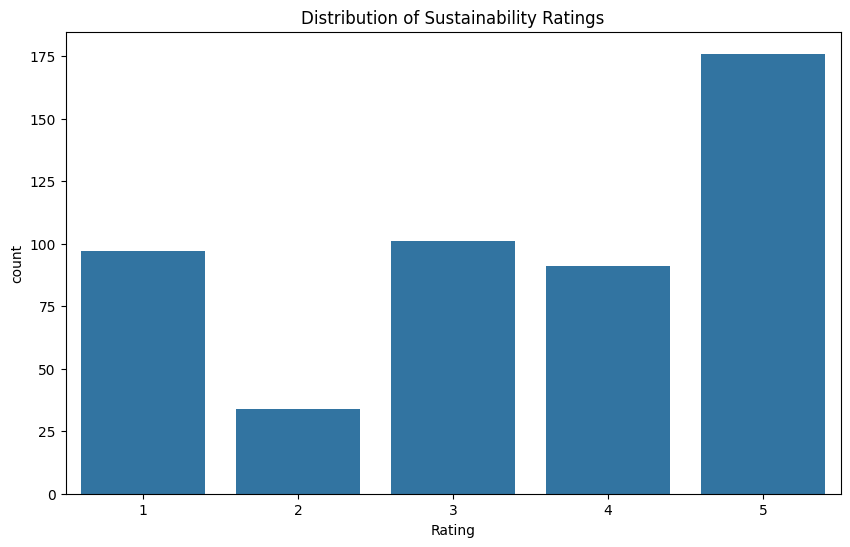

In [32]:
# Visualization of data distributions
plt.figure(figsize=(10, 6))
sns.countplot(x='Rating', data=data)
plt.title('Distribution of Sustainability Ratings')
plt.show()

In [33]:
# Model training and evaluation
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Model prediction and performance evaluation
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 0.8018750000000003
R-squared: 0.6810235092883568


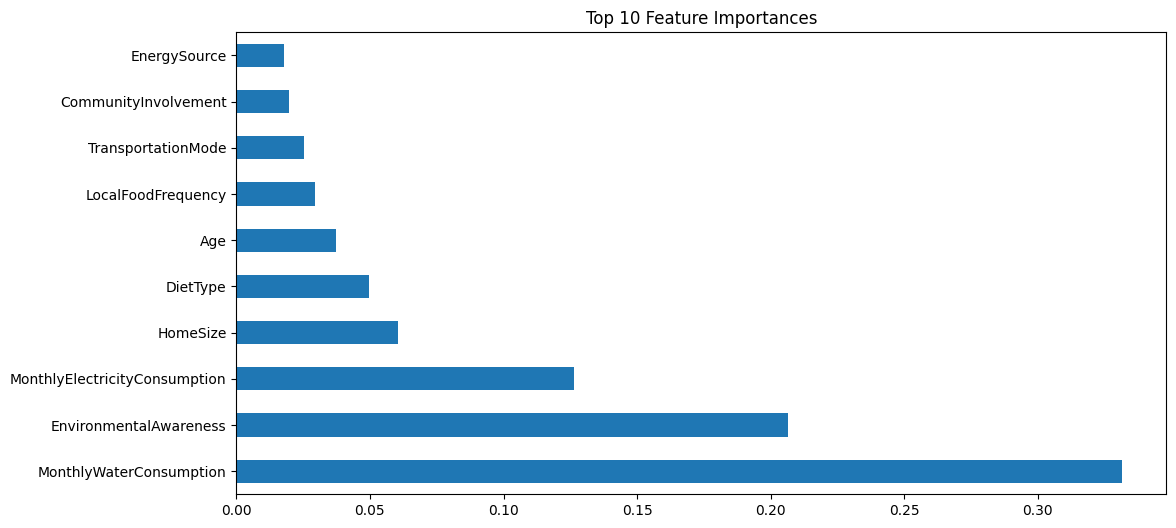

In [34]:
# Feature importance visualization
plt.figure(figsize=(12, 6))
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Feature Importances')
plt.show()

In [35]:
# Initialize and train the Gradient Boosting model
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_gb = gb_model.predict(X_test)
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Regressor Results")
print("Mean Squared Error:", mse_gb)
print("R-squared:", r2_gb)

Gradient Boosting Regressor Results
Mean Squared Error: 0.7319403447104186
R-squared: 0.708842696722058


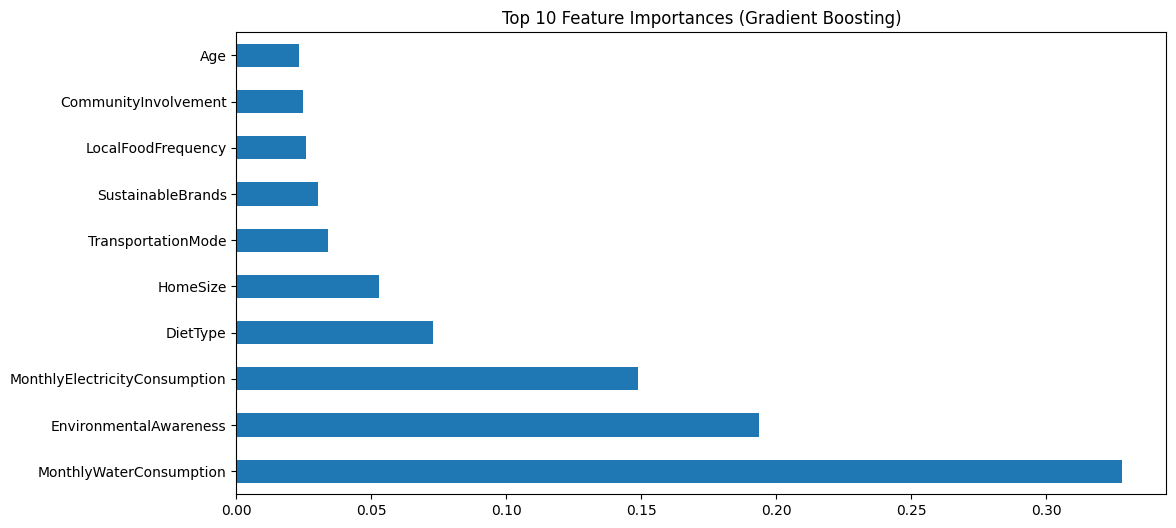

In [36]:
plt.figure(figsize=(12, 6))
feature_importances_gb = pd.Series(gb_model.feature_importances_, index=X.columns)
feature_importances_gb.nlargest(10).plot(kind='barh')
plt.title('Top 10 Feature Importances (Gradient Boosting)')
plt.show()

In [37]:
# Define test case values in a dictionary matching the column names
test_case_data = {
    'Age': [45],
    'Location': ['Suburban'],
    'DietType': ['Mostly Animal-Based'],
    'LocalFoodFrequency': ['Rarely'],
    'TransportationMode': ['Car'],
    'EnergySource': ['Non-Renewable'],
    'HomeType': ['House'],
    'HomeSize': [2000],
    'ClothingFrequency': ['Often'],
    'SustainableBrands': [False],
    'EnvironmentalAwareness': [2],
    'CommunityInvolvement': ['Low'],
    'MonthlyElectricityConsumption': [1000],
    'MonthlyWaterConsumption': [8000],
    'Gender': ['Male'],
    'UsingPlasticProducts': ['Often'],
    'DisposalMethods': ['Landfill'],
    'PhysicalActivities': ['Low']
}

# Convert to DataFrame
test_case_df = pd.DataFrame(test_case_data)

# Apply label encoding to categorical features in test case
for column in ['Location', 'DietType', 'LocalFoodFrequency', 'TransportationMode', 'EnergySource',
               'HomeType', 'ClothingFrequency', 'SustainableBrands', 'CommunityInvolvement', 'Gender',
               'UsingPlasticProducts', 'DisposalMethods', 'PhysicalActivities']:
    test_case_df[column] = label_encoders[column].transform(test_case_df[column])

numerical_columns = ['Age', 'HomeSize', 'MonthlyElectricityConsumption', 'MonthlyWaterConsumption',
                      'EnvironmentalAwareness']

# Scale numerical features in test case
test_case_df[numerical_columns] = scaler.transform(test_case_df[numerical_columns])

# Predict rating for test case using the trained model
predicted_rating = gb_model.predict(test_case_df)
print("Predicted Sustainability Rating:", predicted_rating[0])

Predicted Sustainability Rating: 1.0633605442897192
